In [27]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"
DATABASE = "llmagraphtrkg"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

In [28]:

COUNT_QUERY = """
RETURN
  count{ (:Document) }   AS documents,
  count{ (:Chunk) }      AS chunks,
  count{ (:Entity) } AS entities
"""

REL_COUNT_QUERY = """
MATCH ()-[r]->()
RETURN count(r) AS relationships
"""

In [3]:



with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_before = pd.DataFrame([{
    "stage": "before",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])

stats_before.to_csv("kg_stats_before_new.csv", index=False)
stats_before


,stage,documents,chunks,entities,relationships
0,before,136,2136,3988,25486


In [29]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_after = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])
stats_after

,stage,documents,chunks,entities,relationships
0,after,136,2136,3945,25417


In [30]:
stats_before = pd.read_csv("kg_stats_before.csv")
stats_all = pd.concat([stats_before, stats_after], ignore_index=True)
stats_all


,stage,documents,chunks,entities,relationships
0,before,136,2136,4028,25519
1,after,136,2136,3945,25417


In [17]:
stats_long = stats_all.melt(
    id_vars="stage",
    value_vars=["entities", "relationships"],
    var_name="type",
    value_name="count",
)

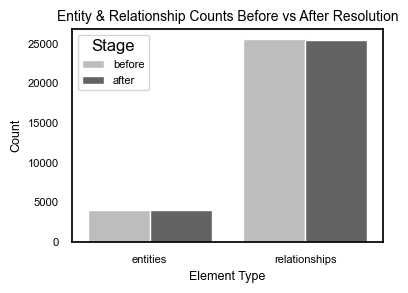

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Theme ---
sns.set_theme(style="white")


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

neutral_palette = ["#bdbdbd", "#636363"]  

plt.figure(figsize=(4, 3))

sns.barplot(
    data=stats_long,
    x="type",          # entities / relationships
    y="count",
    hue="stage",       # BEFORE vs AFTER KG-Build
    palette=neutral_palette
)

plt.title("Entity & Relationship Counts Before vs After Resolution")
plt.xlabel("Element Type")
plt.ylabel("Count")
plt.xticks(rotation=0)


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("black")


legend = ax.legend(title="Stage")
plt.setp(legend.get_texts(), color="black")
plt.setp(legend.get_title(), color="black")

plt.tight_layout()
plt.show()


In [23]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"
DATABASE = "llmakg"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

In [24]:

COUNT_QUERY = """
RETURN
  count{ (:Document) }   AS documents,
  count{ (:Chunk) }      AS chunks,
  count{ (:__Entity__) } AS entities
"""

REL_COUNT_QUERY = """
MATCH ()-[r]->()
RETURN count(r) AS relationships
"""

In [8]:



with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_before = pd.DataFrame([{
    "stage": "before",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])

stats_before.to_csv("kg_stats_before_llmaindex_new.csv", index=False)
stats_before


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Document)} {position: line: 3, column: 12, offset: 19} for query: '\nRETURN\n  count{ (:Document) }   AS documents,\n  count{ (:Chunk) }      AS chunks,\n  count{ (:__Entity__) } AS entities\n'


,stage,documents,chunks,entities,relationships
0,before,0,2832,9806,33325


In [25]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_after = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])
stats_after

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Document)} {position: line: 3, column: 12, offset: 19} for query: '\nRETURN\n  count{ (:Document) }   AS documents,\n  count{ (:Chunk) }      AS chunks,\n  count{ (:__Entity__) } AS entities\n'


,stage,documents,chunks,entities,relationships
0,after,0,2832,9633,33232


In [26]:
stats_before = pd.read_csv("kg_stats_before_llmaindex.csv")
stats_all = pd.concat([stats_before, stats_after], ignore_index=True)
stats_all


,stage,documents,chunks,entities,relationships
0,before,0,2832,10022,33410
1,after,0,2832,9633,33232


In [27]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_after = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])
stats_after

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Document)} {position: line: 3, column: 12, offset: 19} for query: '\nRETURN\n  count{ (:Document) }   AS documents,\n  count{ (:Chunk) }      AS chunks,\n  count{ (:__Entity__) } AS entities\n'


,stage,documents,chunks,entities,relationships
0,after,0,2832,9806,33325


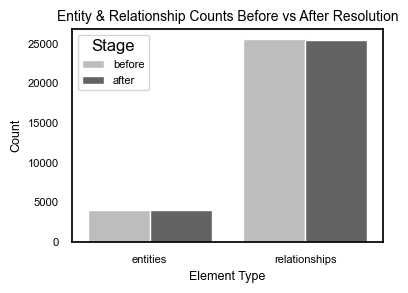

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Theme ---
sns.set_theme(style="white")


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})


neutral_palette = ["#bdbdbd", "#636363"]  #

plt.figure(figsize=(4, 3))

sns.barplot(
    data=stats_long,
    x="type",          
    y="count",
    hue="stage",       
    palette=neutral_palette
)

plt.title("Entity & Relationship Counts Before vs After Resolution")
plt.xlabel("Element Type")
plt.ylabel("Count")
plt.xticks(rotation=0)


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("black")


legend = ax.legend(title="Stage")
plt.setp(legend.get_texts(), color="black")
plt.setp(legend.get_title(), color="black")

plt.tight_layout()
plt.show()


In [19]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"
DATABASE = "simplekg"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

COUNT_QUERY = """
RETURN
  count{ (:Document) }   AS documents,
  count{ (:Chunk) }      AS chunks,
  count{ (:__Entity__) } AS entities
"""

REL_COUNT_QUERY = """
MATCH ()-[r]->()
RETURN count(r) AS relationships
"""

In [10]:



with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_before = pd.DataFrame([{
    "stage": "before",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])

stats_before.to_csv("kg_stats_before_simplekg_new.csv", index=False)
stats_before


,stage,documents,chunks,entities,relationships
0,before,3044,3046,5403,19841


In [20]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_after = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])
stats_after

,stage,documents,chunks,entities,relationships
0,after,3044,3046,5357,19608


In [22]:
stats_before = pd.read_csv("kg_stats_before_simplekg.csv")
stats_all = pd.concat([stats_before, stats_after], ignore_index=True)
stats_all


,stage,documents,chunks,entities,relationships
0,before,3044,3046,5502,20122
1,after,3044,3046,5357,19608


In [19]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_after = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])
stats_after

,stage,documents,chunks,entities,relationships
0,after,3044,3046,5403,19841


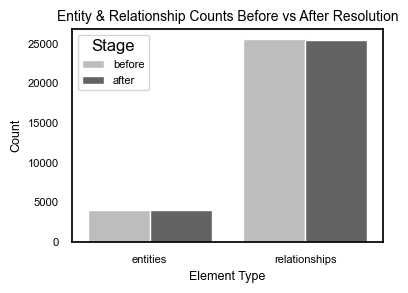

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Theme ---
sns.set_theme(style="white")

# --- Schriftarten & Farben (klar schwarz) ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

# --- Farben (professionelle neutrale Palette) ---
neutral_palette = ["#bdbdbd", "#636363"]  # Hellgrau / Dunkelgrau

plt.figure(figsize=(4, 3))

sns.barplot(
    data=stats_long,
    x="type",          # entities / relationships
    y="count",
    hue="stage",       # BEFORE vs AFTER KG-Build
    palette=neutral_palette
)

plt.title("Entity & Relationship Counts Before vs After Resolution")
plt.xlabel("Element Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("black")


legend = ax.legend(title="Stage")
plt.setp(legend.get_texts(), color="black")
plt.setp(legend.get_title(), color="black")

plt.tight_layout()
plt.show()
